Image shape: (256, 256)
Image min/max values: 7/255


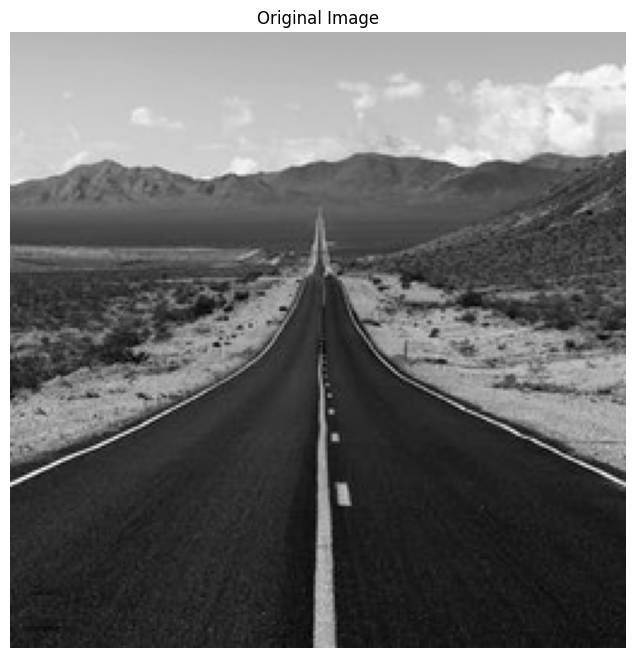

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load the road.bmp image
image_path = "road.bmp"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display original image
plt.figure(figsize=(12, 8))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

print(f"Image shape: {img.shape}")
print(f"Image min/max values: {img.min()}/{img.max()}")

In [ ]:
def apply_padding(image, pad_size=1, mode='reflect'):
    """
    Apply padding to the image for border handling
    mode: 'reflect', 'constant', 'edge'
    """
    if mode == 'reflect':
        # Reflect padding
        padded = np.pad(image, pad_size, mode='reflect')
    elif mode == 'constant':
        # Zero padding
        padded = np.pad(image, pad_size, mode='constant', constant_values=0)
    elif mode == 'edge':
        # Edge padding (replicate border pixels)
        padded = np.pad(image, pad_size, mode='edge')

    return padded

def convolution(image, kernel):
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Calculate padding size
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    padded_img = apply_padding(image, pad_h, mode='constant')

    # Initialize output image
    output = np.zeros_like(image, dtype=np.float64)

    # Perform convolution
    for i in range(img_h):
        for j in range(img_w):
            # Extract the region of interest
            roi = padded_img[i:i+kernel_h, j:j+kernel_w]
            # Apply kernel and sum
            output[i, j] = np.sum(roi * kernel)

    return output

Standard Average Filter Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

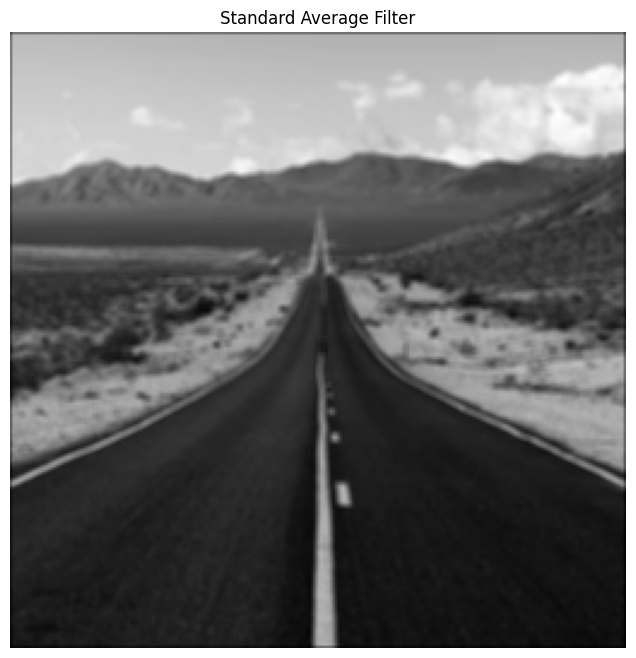

In [ ]:
# Filter 1: Standard Average Filter (3x3)
def standard_average_filter(image):

    kernel = np.ones((3, 3)) / 9
    print("Standard Average Filter Kernel:")
    print(kernel)

    result = convolution(image, kernel)

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply Standard Average Filter
avg_filtered = standard_average_filter(img)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(avg_filtered, cmap='gray')
plt.title('Standard Average Filter')
plt.axis('off')

Weighted Average Filter Kernel:
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

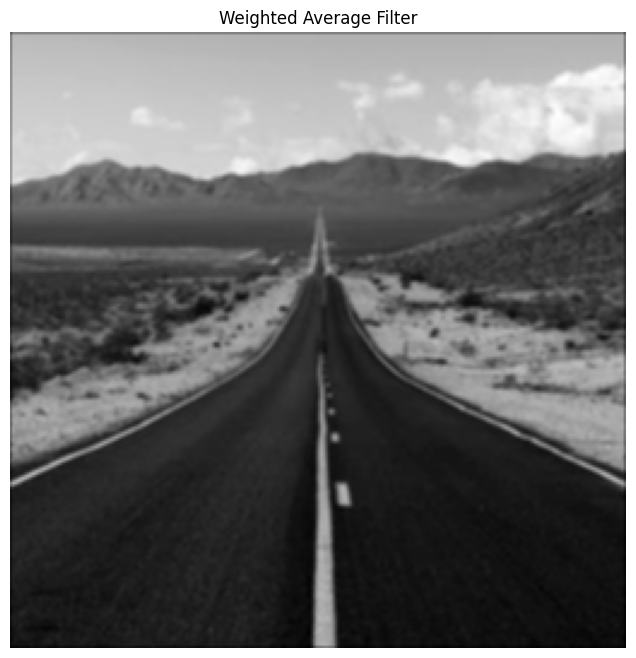

In [ ]:
# Filter 2: Weighted Average Filter (3x3)
def weighted_average_filter(image):

    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]]) / 16
    print("Weighted Average Filter Kernel:")
    print(kernel)

    result = convolution(image, kernel)

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply Weighted Average Filter
weighted_filtered = weighted_average_filter(img)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(weighted_filtered, cmap='gray')
plt.title('Weighted Average Filter')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

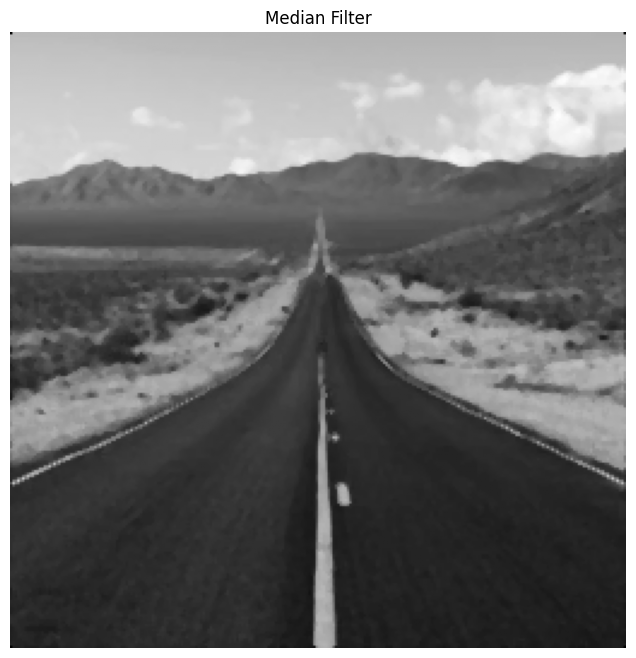

In [ ]:
# Filter 3: Median Filter (3x3)
def median_filter(image):
    """
    Apply median filter with 3x3 window
    Manual implementation without built-in functions
    """
    img_h, img_w = image.shape

    # Apply padding
    padded_img = apply_padding(image, 1, mode='constant')

    # Initialize output
    result = np.zeros_like(image)

    # Apply median filter
    for i in range(img_h):
        for j in range(img_w):
            # Extract 3x3 window
            window = padded_img[i:i+3, j:j+3]

            # Flatten and sort to find median
            window_flat = window.flatten()
            window_sorted = np.sort(window_flat)

            # Get median (middle value)
            median_value = window_sorted[4]  # 5th element (index 4) is median of 9 elements
            result[i, j] = median_value

    return result.astype(np.uint8)

# Apply Median Filter
median_filtered = median_filter(img)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filter')
plt.axis('off')

Laplacian Filter Kernel:
[[ 0 -1  0]
 [-1  4 -1]
 [ 0 -1  0]]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

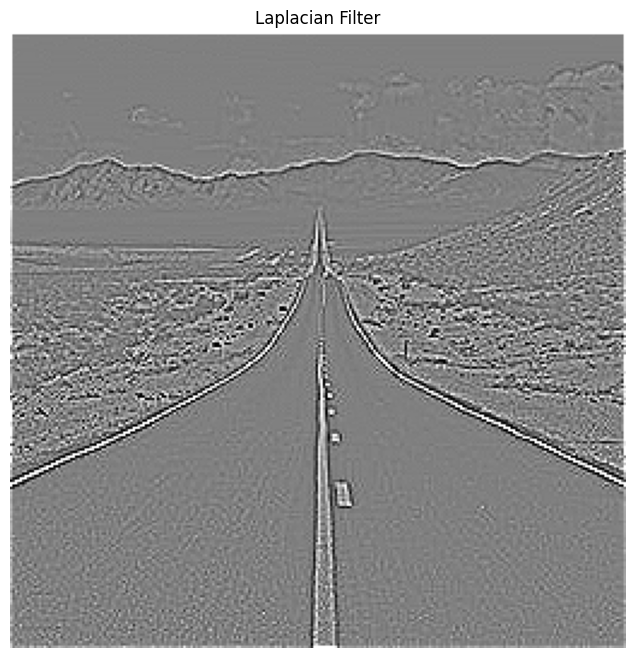

In [ ]:
# Filter 4: Laplacian Filter (3x3)
def laplacian_filter(image):
    """
    Apply Laplacian filter with 3x3 kernel for edge detection
    """
    # Standard Laplacian kernel
    kernel = np.array([[ 0, -1,  0],
                       [-1,  4, -1],
                       [ 0, -1,  0]])

    print("Laplacian Filter Kernel:")
    print(kernel)

    result = convolution(image, kernel)

    # Handle negative values - shift to positive range
    result = result + 128  # Shift by 128 to center around gray

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply Laplacian Filter
laplacian_filtered = laplacian_filter(img)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(laplacian_filtered, cmap='gray')
plt.title('Laplacian Filter')
plt.axis('off')

High-boost Filter with k = 1.5
Formula: Original + k * (Original - Blurred)


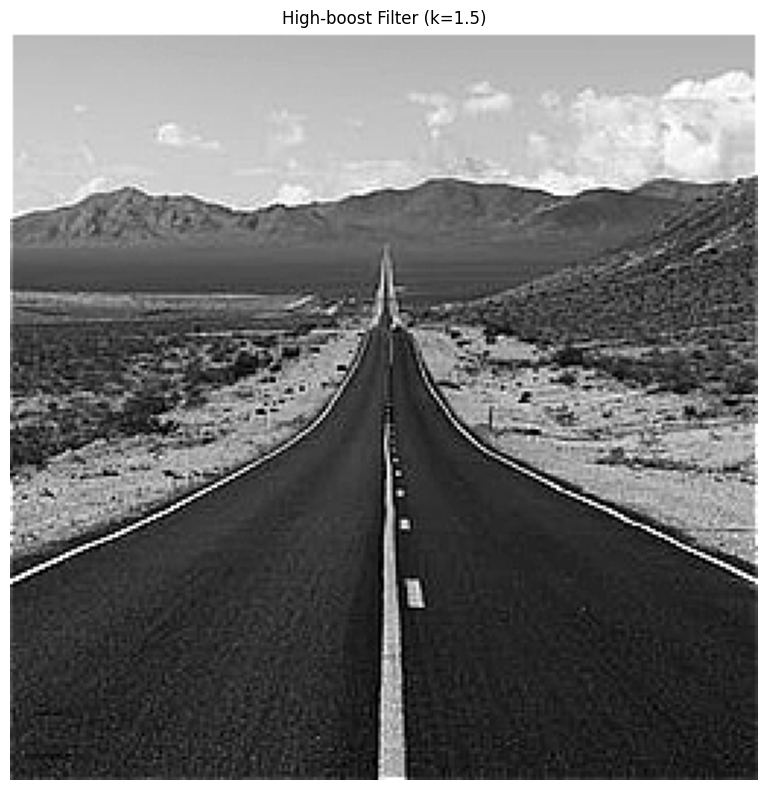

In [ ]:
# Filter 5: High-boost Filter (3x3)
def highboost_filter(image, k=1.5):


    avg_kernel = np.ones((3, 3)) / 9
    blurred = convolution(image, avg_kernel)

    # Calculate high-frequency component
    high_freq = image.astype(np.float64) - blurred

    # Apply high-boost formula
    result = image.astype(np.float64) + k * high_freq

    print(f"High-boost Filter with k = {k}")
    print("Formula: Original + k * (Original - Blurred)")

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply High-boost Filter
highboost_filtered = highboost_filter(img, k=1.5)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(highboost_filtered, cmap='gray')
plt.title('High-boost Filter (k=1.5)')
plt.axis('off')

plt.tight_layout()
plt.show()